<a href="https://colab.research.google.com/github/EhsanNikpey/machine-learning-fundamentals/blob/main/pca_hyperspectral_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STATISTICAL LEARNING AND NEURAL NETWORKS, A.A. 2022/2023**

**COMPUTER LAB 3** - Principal component analysis

**Duration: 3 hours**

**Introduction:**

Hyperspectral images are scientific images of the Earth, acquired by satellites or aicrafts; rather than having three R/G/B color channels, these images have a lot more “color” components obtained through a fine sampling of the wavelength (hence the name “hyper”-spectral). The
resulting 3-dimensional dataset has one image (spectral band or “color”) for every sampled wavelength, which represents the measured radiance from each pixel at that specific wavelength. Hyperspectral images are very useful for image analysis. For every pixel at a given spatial position, it is possible to extract a so-called spectral vector, i.e. the 1-dimensional vector of values assumed by that pixel at all wavelengths. Assuming that each pixel is composed of just one substance, the spectral vector represents the radiance of that substance at all the wavelengths that have been
sampled. Spectral vectors, therefore, can be used to infer which substance is contained in a given pixel – a typical classification problem that has a lot of practical applications in agriculture, analysis of land use / land cover, and other applications related to the study of the environment.


In this lab you will use a real hyperspectral image that has been acquired by the AVIRIS instrument, an airborne hyperspectral imager operated by the NASA. The image represents a scene of Indian Pines (Indiana, USA). It has a size of 145x145 pixels and 220 spectral bands. Along with the image, a ground truth is available, in terms of labels specifying which class (out of 16) each pixel belongs to. The classes are reported below; for more information, please see
http://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes#Indian_Pines

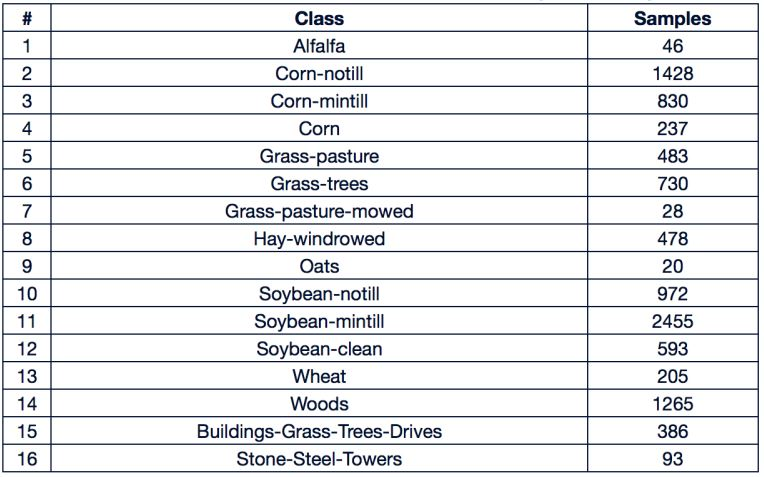

The purpose of this computer lab is twofold:
To apply PCA to the spectral vectors in order to reduce their dimensionality.

*   To apply PCA to the spectral vectors in order to reduce their dimensionality.
*   To perform classification on the reduced data (optional)

**Exercise 1 – PCA**


In this exercise, you will employ the Indian Pines dataset. You will not do this for the entire dataset, but only for the spectral vectors belonging to **two classes** (as in the optional exercise you will perform 2-class classification on the PCA coefficients).

**Reminder:** the input to the PCA must always have zero mean: besides the sample covariance, you will have to compute the **mean value μ** over the training set and subtract it from each test vector before applying PCA.

**Task:** You have to reduce the dimensionality of the spectral vectors of the two classes you have chosen using PCA. In particular, you should perform the following:


*   Extract spectral vectors of two classes, as described above (see sample code below).
*   Estimate the sample covariance matrix of the dataset as a whole (i.e., considering together spectral vectors of the two classes)
*   Perform the eigenvector decomposition of the sample covariance matrix. You can use the numpy linalg.eig function, which outputs the matrix containing the eigenvectors as columns, and a diagonal matric containing the eigenvalues on the main diagonal.
  * Note: in the output matrix, eigenvectors/eigenvalues are not necessarily ordered by eigenvalue magnitude. You should sort them by yourself.
*   Choose a number of dimensions K<=220.
*   Construct the eigenvector matrix W for K components (i.e., select the last K columns)
*   Using W, compute the PCA coefficients for each spectral vector in the data set
*   Then from the PCA coefficients obtain an approximation of the corresponding vector and compute the error (mean square error - MSE)
*   Plot the average MSE over the test set as a function of K.
*   Plot the eigenvectors corresponding to the 3 largest eigenvalues – this will give you an idea of the basis functions employed by PCA

In [ ]:
import numpy as np
import h5py
import scipy.io

mat = scipy.io.loadmat('Indian_pines.mat')
indian_pines = np.array(mat['indian_pines']) # For

mat = scipy.io.loadmat('Indian_pines_gt.mat')
indian_pines_gt = np.array(mat['indian_pines_gt'])

In [ ]:
height, width, spectrum = indian_pines.shape

indian_pines = indian_pines.reshape(height*width, 220)   #reshape our data to be flatten
indian_pines_gt = indian_pines_gt.reshape(height*width)
mask = (indian_pines_gt == 5) | (indian_pines_gt == 8)   #choose class of 5 and 8 (| is simbol of or)

indian_pines = indian_pines[mask]
indian_pines_gt = indian_pines_gt[mask]

print(indian_pines.shape)
print(indian_pines_gt.shape)

(961, 220)
(961,)


In [ ]:
# we want to standardize data with formula as x_standard = (x - mean(x))/std(x)

# indian_pines_st = (indian_pines - np.mean(indian_pines))/np.std(indian_pines)
mean_vec = np.mean(indian_pines, axis=0)
indian_pines_st = indian_pines - mean_vec

indian_pines_st = indian_pines - np.mean(indian_pines, axis=0)


**Extract spectral vectors of two classes, as described above (see sample code below).**

In [ ]:
#class1_value =

#class1=np.zeros((1500,220))
#n=0
#for i in range(145):
#  for j in range(145):
#    if indian_pines_gt[i,j]== class1_value:
#      class1[n,:] = indian_pines[i,j,:]/1.
#      n=n+1
#class1=class1[:n,:]

**Estimate the sample covariance matrix of the dataset as a whole (i.e., considering together spectral vectors of the two classes)**

In [ ]:
covariance_matrix = np.cov(indian_pines_st, rowvar=False)

**Perform the eigenvector decomposition of the sample covariance matrix. You can use the numpy linalg.eig function, which outputs the matrix containing the eigenvectors as columns, and a diagonal matric containing the eigenvalues on the main diagonal.**

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

#Note: in the output matrix, eigenvectors/eigenvalues are not necessarily ordered by eigenvalue magnitude. You should sort them first.

**Choose a number of dimensions K<=220.Construct the eigenvector  matrix W for K components (i.e., select the last K columns)**

In [ ]:
K = 118
W = sorted_eigenvectors[:, :K]
W.shape

(220, 118)

**Using W, compute the PCA coefficients for each spectral vector in the data set. Then from the PCA coefficients obtain an approximation of the corresponding vector and compute the error (mean square error - MSE)**

In [ ]:
#Note: remember to remove the mean from the vectors of the dataset

Z = indian_pines_st @ W
print(Z.shape)

(961, 118)


In [ ]:
indian_pines_reconstructed = Z @ W.T

In [ ]:
# indian_pines_approx = indian_pines_reconstructed * np.std(indian_pines) + np.mean(indian_pines)
indian_pines_approx = indian_pines_reconstructed + mean_vec

mse = np.mean((indian_pines - indian_pines_approx) ** 2)
print (mse)

11.694641284804154


In [ ]:
mse_values = []
for K in range(1, 221):  # Or your desired range of K values
    W = sorted_eigenvectors[:, :K]
    Z = indian_pines_st @ W
    indian_pines_reconstructed = Z @ W.T
    indian_pines_approx = indian_pines_reconstructed + mean_vec
    mse = np.mean((indian_pines - indian_pines_approx) ** 2)
    mse_values.append(mse)

**Plot the average MSE over the test set as a function of K.**

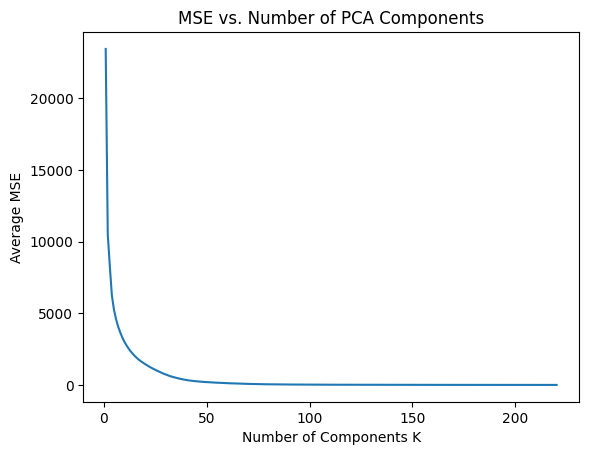

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(1, 221), mse_values)
plt.xlabel('Number of Components K')
plt.ylabel('Average MSE')
plt.title('MSE vs. Number of PCA Components')
plt.show()

**Plot the eigenvectors corresponding to the 3 largest eigenvalues – this will give you an idea of the basis functions employed by PCA**

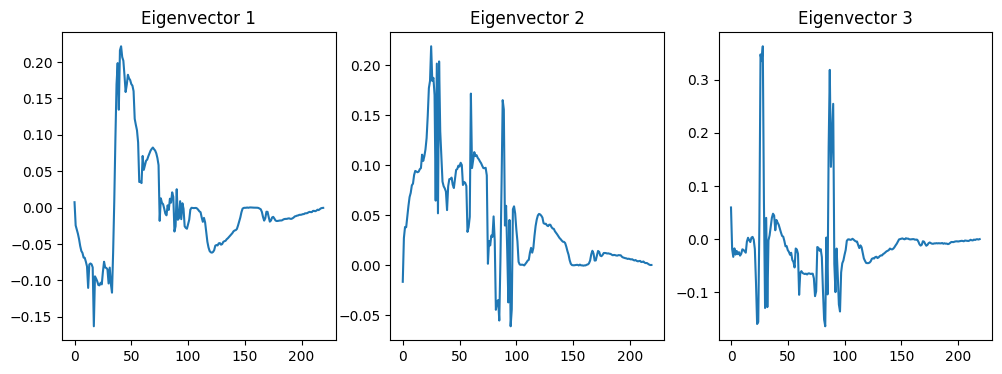

In [ ]:
top_3_eigenvectors = sorted_eigenvectors[:, :3]
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(top_3_eigenvectors[:, i])
    plt.title(f'Eigenvector {i + 1}')
plt.show()

The exercise demonstrates the application of Principal Component Analysis (PCA) for dimensionality reduction on hyperspectral image data from the Indian Pines dataset. By focusing on two selected classes (Classes 5 and 8), the data was standardized to have zero mean, ensuring proper PCA computation. The sample covariance matrix was used to calculate eigenvalues and eigenvectors, which were sorted to identify the principal components explaining the most variance. Dimensionality reduction was achieved by projecting data into a lower-dimensional space using the top
K eigenvectors and reconstructing it to measure reconstruction accuracy through Mean Square Error (MSE). The MSE plot versus the number of components
K revealed that adding more components improves reconstruction accuracy, with diminishing returns as
K approaches the total number of dimensions (220).

The results show that PCA effectively reduces dimensionality while preserving essential spectral information, making it useful for downstream tasks like classification. Visualization of eigenvectors corresponding to the largest eigenvalues provided insights into the dominant patterns in the hyperspectral data, reflecting significant spectral characteristics of the classes. This exercise highlights PCA's ability to balance computational efficiency and data accuracy, offering a robust approach for analyzing high-dimensional data like hyperspectral images.